# 09v2 - Multi-Model Operational Evaluation

Evaluates **8 trained models** (from NB08) at scene level across two feature groups:

| Group | Models | Data source |
|-------|--------|-------------|
| A (S2/GRD) | S2-only SVM, S2-only RF, S2+GRD RF | `training_samples_fusion.csv` |
| B (+Coh) | S2+Coh SVM, S2+CohJumps SVM, Coh-only SVM, Coh-only RF, Full-fusion SVM | `training_samples_fusion_coh.csv` |

<br> 

> **Note:** Group A and Group B used different test populations in NB08.  \
> Scene-level calibration (Section 4) corrects thresholds independently per model.

**Workflow:**
1. Load models â†’ feature/threshold summary  \
2. Programmatic scene inventory (cloud + coherence coverage)  \
3. Feature preparation helpers (S2 + optional GRD + optional coherence)  \
4. Leave-one-out threshold calibration  \
5. Postprocessing parameter grid search  \
6. Scene-level evaluation on held-out scenes  \
7. Non-event control test (specificity)  \
8. Comprehensive results summary  `data/operational_results/eval_summary.csv`

---
## 1. Setup and Model Loading

In [1]:
import sys
import os
import importlib
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import f1_score as _f1_score

sys.path.insert(0, os.path.abspath('..'))

import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import (
    FEATURE_NAMES, prepare_scene_features, run_prediction,
    evaluate_and_visualize, find_optimal_threshold,
)
from src.postprocessing import postprocess_prediction
from src.config import (
    MODELS_DIR, RESULTS_DIR, S2_SCENES_DIR, GT_MASKS_DIR,
    AV_LANDUSE_PATH, AV_FIREBRIGADE_PATH, TEMPORAL_MATCHES_CSV,
    COH_DIR, S1_FEATURES_DIR, CLOUD_THRESHOLD, DOCS_DIR
)

CLOUD_BAND = 13          # band index in S2 TIF (1-based)
S2_DIR       = S2_SCENES_DIR
MASKS_DIR    = GT_MASKS_DIR
AV_DATA_PATH = AV_LANDUSE_PATH
FB_DATA_PATH = AV_FIREBRIGADE_PATH
OUTPUT_DIR   = RESULTS_DIR / "evaluation"

# Images for report
IMG_DIR = DOCS_DIR

COH_FEATURES = ['coh_vv_jump', 'coh_vh_jump']
SAR_FEATURES = ['vh_after', 'vv_after', 'vh_diff'] 

# 8 models
EVAL_MODELS = {
    # S2 baseline: best vs diff (PW2 hypothesis test)
    's2_only_best_rf':   'models/s2_only_best_rf.joblib',
    's2_only_best_svm':  'models/s2_only_best_svm.joblib',    # RF vs SVM comparison
    's2_only_diff_rf':   'models/s2_only_diff_rf.joblib',
    's2_only_diff_svm':  'models/s2_only_diff_svm.joblib',    # RF vs SVM on diff features
    
    # Coherence fusion: does quadruplet coherence help S2?
    's2_best_coh_rf':    'models/s2_best_coh_rf.joblib',
    's2_diff_coh_rf':    'models/s2_diff_coh_rf.joblib',
    
    # GRD fusion: does GRD help S2?
    's2_grd_rf':        'models/s2_grd_rf.joblib',
    
    # Kitchen sink
    'full_fusion_rf':   'models/full_fusion_rf.joblib',
    
    # Standalone radar ablations (expected to fail, documented)
    'coh_only_rf':      'models/coh_only_rf.joblib',
    'grd_only_rf':      'models/grd_only_rf.joblib',
}

NEEDS_COH = {k: any(x in k for x in ('coh', 'full')) for k in EVAL_MODELS}
NEEDS_GRD = {k: any(x in k for x in ('grd', 'full')) for k in EVAL_MODELS}

print('Setup complete.')


Setup complete.


In [2]:
def load_saved_model(rel_path):
    abs_path = Path('..') / rel_path
    if not abs_path.exists():
        print(f'  NOT FOUND: {abs_path}')
        return None, [], 0.5
    obj = joblib.load(abs_path)
    if isinstance(obj, dict):
        return obj['model'], obj.get('features', FEATURE_NAMES), float(obj.get('threshold', 0.5))
    return obj, FEATURE_NAMES, 0.5

MODEL_REGISTRY = {}
rows = []
for name, rel_path in EVAL_MODELS.items():
    model, features, threshold = load_saved_model(rel_path)
    MODEL_REGISTRY[name] = {
        'model': model, 'features': features,
        'threshold': threshold, 'calibrated_threshold': threshold,
    }
    rows.append({
        'name':            name,
        'algorithm':       rel_path.replace('.joblib', '').split('_')[-1].upper(),
        'n_features':      len(features),
        'train_threshold': round(threshold, 3),
        'needs_coh':       NEEDS_COH[name],
        'needs_grd':       NEEDS_GRD[name],
        'loaded':          model is not None,
    })

print('Loaded models:')
print(pd.DataFrame(rows).to_string(index=False))


Loaded models:
            name algorithm  n_features  train_threshold  needs_coh  needs_grd  loaded
 s2_only_best_rf        RF           5             0.95      False      False    True
s2_only_best_svm       SVM           5             0.90      False      False    True
 s2_only_diff_rf        RF           3             0.90      False      False    True
s2_only_diff_svm       SVM           3             0.90      False      False    True
  s2_best_coh_rf        RF           7             0.90       True      False    True
  s2_diff_coh_rf        RF           5             0.90       True      False    True
       s2_grd_rf        RF           8             0.75      False       True    True
  full_fusion_rf        RF          10             0.80       True       True    True
     coh_only_rf        RF           2             0.10       True      False    True
     grd_only_rf        RF           3             0.45      False       True    True


---
## 2. Automated Scene Inventory

Scans all events in `temporal_matches.csv` and computes the cloud-free pixel fraction for each before/after pair within the grassland+airport AOI.

**Filters applied:** April: October only, gap: 15 days, pct\_valid: 40%.

The final inventory shows which events have coherence data and GRD features available,
so you can select calibration/evaluation/control scenes based on coverage and data availability.

In [3]:
import geopandas as gpd
from rasterio import features as rio_features

matches_df = pd.read_csv(TEMPORAL_MATCHES_CSV)
matches_df.insert(0, 'match_id', matches_df.index)
matches_df['event_date'] = pd.to_datetime(matches_df['event_date'])

# Build AOI (grassland âˆ© airport) mask once, cache by scene grid dimensions
_aoi_mask_cache = {}

def _build_aoi_mask(meta, H, W):
    crs = meta['crs']
    transform = meta['transform']
    av = gpd.read_file(AV_DATA_PATH, layer='Bodenbedeckung_BoFlaeche_Area').to_crs(crs)
    gl = av[av['Art_TXT'] == 'humusiert.Acker_Wiese_Weide']
    gl_mask = rio_features.rasterize(
        gl.geometry, out_shape=(H, W), transform=transform,
        fill=0, default_value=1, dtype='uint8',
    ).astype(bool) if len(gl) > 0 else np.zeros((H, W), dtype=bool)

    fb = gpd.read_file(FB_DATA_PATH, layer='FW_GEMEINDEN_F').to_crs(crs)
    ap = fb[fb['GEMEINDENAME'] == 'Flughafen ZÃ¼rich']
    ap_mask = rio_features.rasterize(
        ap.geometry, out_shape=(H, W), transform=transform,
        fill=0, default_value=1, dtype='uint8',
    ).astype(bool) if not ap.empty else np.ones((H, W), dtype=bool)

    return (gl_mask & ap_mask).flatten()

inventory_rows = []
for _, row in matches_df.iterrows():
    mid = int(row['match_id'])
    event_date = row['event_date']
    if not (4 <= event_date.month <= 10):
        continue

    before_path = S2_DIR / row['before_near_file']
    after_path  = S2_DIR / row['after_file']
    if not (before_path.exists() and after_path.exists()):
        continue

    before_date = pd.to_datetime(row['before_near_file'].replace('.tif', ''))
    after_date  = pd.to_datetime(row['after_file'].replace('.tif', ''))
    gap_days    = (after_date - before_date).days
    if gap_days > 15:
        continue

    with rasterio.open(str(before_path)) as src_b, rasterio.open(str(after_path)) as src_a:
        meta = src_b.meta.copy()
        H, W = meta['height'], meta['width']
        cache_key = (H, W, str(meta['transform']))
        if cache_key not in _aoi_mask_cache:
            _aoi_mask_cache[cache_key] = _build_aoi_mask(meta, H, W)
        aoi_mask = _aoi_mask_cache[cache_key]
        cloud_b = src_b.read(CLOUD_BAND).astype(float).flatten()
        cloud_a = src_a.read(CLOUD_BAND).astype(float).flatten()

    cloud_free = (cloud_b < CLOUD_THRESHOLD) & (cloud_a < CLOUD_THRESHOLD)
    n_aoi      = int(aoi_mask.sum())
    n_valid    = int((aoi_mask & cloud_free).sum())
    pct_valid  = round(n_valid / n_aoi * 100, 1) if n_aoi > 0 else 0.0

    has_coh = (
        (Path(COH_DIR) / f'{mid}_coh_before_snrcorr.tif').exists() and
        (Path(COH_DIR) / f'{mid}_coh_after_snrcorr.tif').exists()
    )
    has_grd = (Path(S1_FEATURES_DIR) / f'{mid}_s1_features.tif').exists()
    has_gt  = (Path(MASKS_DIR) / row['mask_file']).exists()

    inventory_rows.append({
        'match_id':    mid,
        'event_date':  event_date.date(),
        'before_date': str(before_date.date()),
        'after_date':  str(after_date.date()),
        'gap_days':    gap_days,
        'n_valid_px':  n_valid,
        'pct_valid':   pct_valid,
        'has_coh':     has_coh,
        'has_grd':     has_grd,
        'has_gt':      has_gt,
    })

inventory_df = pd.DataFrame(inventory_rows)
print(f'Total candidates (Apr-Oct, gapâ‰¤15d): {len(inventory_df)}')
print(f'  pct_valid >= 40%: {(inventory_df["pct_valid"] >= 40).sum()}')
print(f'  with coherence:   {inventory_df["has_coh"].sum()}')
print(f'  with GRD:         {inventory_df["has_grd"].sum()}')


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


Total candidates (Apr-Oct, gapâ‰¤15d): 92
  pct_valid >= 40%: 47
  with coherence:   36
  with GRD:         92


In [4]:
# Deduplicate by image pair - multiple events can share the same (before, after) images.
# GT evaluation already unions all masks per image pair (_load_gt_flat uses after_file),
# so using any one match_id from a group is correct. But picking multiple from the same
# group for calib/eval would mean calibrating or evaluating on the identical scene twice
# (calib) or leaking the calibration scene into eval (calib/eval split).
#
# unique_inventory_df contains ONE row per unique image pair (lowest match_id as
# representative). co_events lists all other match_ids that share the same image pair.
# Always select from unique_inventory_df - never use both IDs from a co-event group.

pair_key = inventory_df['before_date'].astype(str) + '__' + inventory_df['after_date'].astype(str)
inventory_df['_pair_key'] = pair_key

# Build co_events mapping
co_events_map = (
    inventory_df.groupby('_pair_key')['match_id']
    .apply(lambda ids: sorted(ids.tolist()))
    .to_dict()
)

unique_rows = []
for _, row in inventory_df.sort_values('match_id').drop_duplicates('_pair_key').iterrows():
    all_ids = co_events_map[row['_pair_key']]
    others  = [i for i in all_ids if i != row['match_id']]
    r = row.drop('_pair_key').to_dict()
    r['co_events'] = others if others else []
    unique_rows.append(r)

unique_inventory_df = pd.DataFrame(unique_rows)
inventory_df.drop(columns='_pair_key', inplace=True)

n_dup_pairs = (unique_inventory_df['co_events'].apply(len) > 0).sum()
print(f'Unique image pairs: {len(unique_inventory_df)}  '
      f'({n_dup_pairs} pairs have co-events - multiple mowings between same dates)\n')

inv_sorted = unique_inventory_df.sort_values('pct_valid', ascending=False)

print('=== ALL UNIQUE SCENE PAIRS (sorted by cloud-free coverage) ===')
print(inv_sorted.to_string(index=False))

print()
print('=== WITH COHERENCE DATA ===')
print(inv_sorted[inv_sorted['has_coh']].to_string(index=False))

print()
print('=== WITHOUT COHERENCE DATA ===')
print(inv_sorted[~inv_sorted['has_coh']].to_string(index=False))

Unique image pairs: 67  (25 pairs have co-events - multiple mowings between same dates)

=== ALL UNIQUE SCENE PAIRS (sorted by cloud-free coverage) ===
 match_id event_date before_date after_date  gap_days  n_valid_px  pct_valid  has_coh  has_grd  has_gt co_events
       15 2019-07-02  2019-06-29 2019-07-04         5       90582       99.9    False     True    True      [16]
       55 2020-08-05  2020-07-30 2020-08-07         8       90190       99.5    False     True    True        []
       14 2019-06-27  2019-06-24 2019-06-29         5       89970       99.3    False     True    True        []
       84 2023-08-20  2023-08-17 2023-08-22         5       89918       99.2    False     True    True        []
       12 2019-06-23  2019-06-19 2019-06-24         5       89564       98.8     True     True    True        []
       31 2019-09-02  2019-08-30 2019-09-04         5       89342       98.6    False     True    True        []
       30 2019-08-28  2019-08-25 2019-08-30         5    

---
### Scene Pool Selection

Each row in the inventory above represents **one unique image pair** (`before_date â†’ after_date`). The `co_events` column lists other `match_id`s that share the exact same two images - meaning multiple mowing events happened between those dates. Because `_load_gt_flat` always unions **all** GT masks for a given image pair, using any one `match_id` from a co-event group automatically evaluates against the combined ground truth. You do not need to select multiple
IDs from the same group.

**Rules for picking IDs:**
- Select from `unique_inventory_df` only (the deduplicated list above)
- Never put two IDs from the same co-event group into different pools - they are the same scene
- Prefer scenes with `has_gt = True` for calibration and evaluation

**Calibration scenes** (`CALIB_SCENE_IDS`): 5â€“7 scenes with `pct_valid â‰¥ 40%` and `has_gt = True`. Spread across different months for a robust threshold estimate. Include at least 2â€“3 scenes with `has_coh = True` to calibrate coherence-dependent models.

**Evaluation scenes** (`EVAL_SCENE_IDS`): 2â€“3 scenes held out from calibration. Must not share any image pair with a calibration scene.

**Control scene** (`CONTROL_SCENE_ID`): 1 scene for the non-event specificity test (Section 7). Requires a `before_far_file` (all do) and ideally `pct_valid â‰¥ 60%`.


In [12]:
CALIB_SCENE_IDS  = [41, 44, 46, 62, 64]     # list of match_ids,
EVAL_SCENE_IDS   = [12, 73]     # list of match_ids
CONTROL_SCENE_ID = 42   # single match_id, 


print('Calibration scenes:', CALIB_SCENE_IDS)
print('Evaluation scenes: ', EVAL_SCENE_IDS)
print('Control scene:     ', CONTROL_SCENE_ID)

# Guard: detect if any two selected IDs share the same image pair (co-events)
def _image_pair_key(mid):
    row = matches_df[matches_df['match_id'] == mid].iloc[0]
    return (row['before_near_file'], row['after_file'])

all_selected = (list(CALIB_SCENE_IDS) + list(EVAL_SCENE_IDS)
                + ([CONTROL_SCENE_ID] if CONTROL_SCENE_ID is not None else []))

pair_to_ids = {}
for mid in all_selected:
    key = _image_pair_key(mid)
    pair_to_ids.setdefault(key, []).append(mid)

conflicts = {k: v for k, v in pair_to_ids.items() if len(v) > 1}
if conflicts:
    print('\n CO-EVENT CONFLICT - the following IDs share the same image pair:')
    for (bf, af), ids in conflicts.items():
        print(f'  {bf} â†’ {af} : match_ids {ids}')
    print('  Pick only ONE match_id per unique image pair (see inventory co_events column).')
elif all_selected:
    print('\nNo co-event conflicts - all selected IDs use distinct image pairs.')

if not CALIB_SCENE_IDS:
    print('\nFill in CALIB_SCENE_IDS / EVAL_SCENE_IDS / CONTROL_SCENE_ID above, then re-run.')


Calibration scenes: [41, 44, 46, 62, 64]
Evaluation scenes:  [12, 73]
Control scene:      42

No co-event conflicts - all selected IDs use distinct image pairs.


---
## 3. Scene Feature Preparation

Helper functions for loading a full feature matrix given a `match_id`.
- S2 features (20 columns) via `prepare_scene_features` from `src/evaluation.py`
- GRD features (6 columns) from `{match_id}_s1_features.tif` - attached if model needs them
- Coherence features (4 columns) from `{match_id}_coh_before/after.tif` - attached if available

`load_scene_features(match_id)` returns a flat DataFrame with all available columns.
The prediction step selects only the columns each model actually needs.

In [13]:
# â”€â”€ Coherence TIF helpers (same logic as NB09 original) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def _find_coh_bands(src):
    """Return (vv_idx, vh_idx) 1-based band indices for a SNAP coherence TIF."""
    if src.count >= 4:
        return 2, 4      # SNAP: [VV_int, VV_coh, VH_int, VH_coh]
    if src.count == 2:
        return 1, 2
    return 1, None


def _read_coh_upsampled(tif_path, band_idx, ref_path):
    """Read one coherence band and bilinear-upsample to the S2 10 m grid."""
    with rasterio.open(ref_path) as ref:
        dst_shape, dst_transform, dst_crs = (ref.height, ref.width), ref.transform, ref.crs
    with rasterio.open(tif_path) as src:
        arr = src.read(band_idx).astype(np.float32)
        arr[arr <= 0] = np.nan
        dst = np.full(dst_shape, np.nan, dtype=np.float32)
        reproject(arr, dst,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=dst_transform, dst_crs=dst_crs,
                  resampling=Resampling.bilinear,
                  src_nodata=np.nan, dst_nodata=np.nan)
    return dst


def _is_empty_tif(tif_path, band_idx):
    with rasterio.open(tif_path) as src:
        return np.all(src.read(band_idx).astype(np.float32) == 0)


# â”€â”€ S1 GRD feature loader â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def _read_grd_features(match_id, ref_path):
    """
    Load pre-computed S1 GRD features for a match event.
    Returns dict {feature_name: flat_array} or None if file missing.
    Bands are expected in SAR_FEATURES order; falls back to descriptions if available.
    """
    tif_path = Path(S1_FEATURES_DIR) / f'{match_id}_s1_features.tif'
    if not tif_path.exists():
        return None

    with rasterio.open(str(tif_path)) as src:
        H_grd, W_grd = src.height, src.width
        descs = list(src.descriptions) if src.descriptions else []
        bands = {}
        for b in range(1, src.count + 1):
            name = descs[b - 1] if b <= len(descs) and descs[b - 1] else SAR_FEATURES[b - 1] if b <= len(SAR_FEATURES) else f'band{b}'
            arr = src.read(b).astype(np.float32)
            bands[name] = arr

    # Upsample to S2 grid if necessary
    with rasterio.open(ref_path) as ref:
        dst_shape = (ref.height, ref.width)
        if (H_grd, W_grd) == dst_shape:
            return {k: v.flatten() for k, v in bands.items()}
        # Need reprojection
        with rasterio.open(str(tif_path)) as src:
            result = {}
            for b_idx, (name, _) in enumerate(bands.items(), start=1):
                arr = src.read(b_idx).astype(np.float32)
                arr[arr == 0] = np.nan
                dst = np.full(dst_shape, np.nan, dtype=np.float32)
                reproject(arr, dst,
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=ref.transform, dst_crs=ref.crs,
                          resampling=Resampling.bilinear,
                          src_nodata=np.nan, dst_nodata=np.nan)
                result[name] = dst.flatten()
            return result


print('Feature preparation helpers defined.')


Feature preparation helpers defined.


In [14]:
def load_scene_features(match_id):
    """
    Load all available features for one mowing event.

    Returns
    -------
    feature_df    : DataFrame with S2 + (GRD if available) + (coh if available)
    valid_mask    : bool flat array - grassland + airport + cloud-free (S2 only)
    valid_mask_coh: bool flat array - valid_mask & coherence finite (for coh models)
    meta          : rasterio meta dict (from the S2 after-image)
    H, W          : scene dimensions
    """
    row = matches_df[matches_df['match_id'] == match_id].iloc[0]
    before_path = str(S2_DIR / row['before_near_file'])
    after_path  = str(S2_DIR / row['after_file'])

    feature_df, valid_mask, meta, H, W = prepare_scene_features(
        before_path, after_path, AV_DATA_PATH, FB_DATA_PATH, FEATURE_NAMES
    )

    # GRD features
    grd_bands = _read_grd_features(match_id, after_path)
    if grd_bands is not None:
        for fname in SAR_FEATURES:
            if fname in grd_bands:
                feature_df[fname] = grd_bands[fname]
        print(f'  GRD features attached: {[f for f in SAR_FEATURES if f in feature_df.columns]}')
    else:
        print(f'  GRD: no features TIF for match_id={match_id}')

    # Coherence features
    coh_before = str(Path(COH_DIR) / f'{match_id}_coh_before_snrcorr.tif')
    coh_after  = str(Path(COH_DIR) / f'{match_id}_coh_after_snrcorr.tif')
    coh_available = Path(coh_before).exists() and Path(coh_after).exists()

    if coh_available:
        with rasterio.open(coh_after) as sa:
            vv_a_idx, vh_a_idx = _find_coh_bands(sa)
        with rasterio.open(coh_before) as sb:
            vv_b_idx, vh_b_idx = _find_coh_bands(sb)

        before_empty = _is_empty_tif(coh_before, vv_b_idx)

        coh_a_vv = _read_coh_upsampled(coh_after,  vv_a_idx, after_path)
        coh_a_vh = (_read_coh_upsampled(coh_after,  vh_a_idx, after_path)
                    if vh_a_idx else np.full_like(coh_a_vv, np.nan))

        feature_df['coh_vv'] = coh_a_vv.flatten()
        feature_df['coh_vh'] = coh_a_vh.flatten()

        if before_empty:
            print(f'  COH: coh_before is all zeros - setting jump features to 0')
            feature_df['coh_vv_jump'] = 0.0
            feature_df['coh_vh_jump'] = 0.0
        else:
            coh_b_vv = _read_coh_upsampled(coh_before, vv_b_idx, after_path)
            coh_b_vh = (_read_coh_upsampled(coh_before, vh_b_idx, after_path)
                        if vh_b_idx else np.full_like(coh_b_vv, np.nan))
            feature_df['coh_vv_jump'] = (coh_a_vv - coh_b_vv).flatten()
            feature_df['coh_vh_jump'] = (coh_a_vh - coh_b_vh).flatten()

        valid_mask_coh = valid_mask & np.isfinite(feature_df['coh_vv'].values)
        print(f'  COH: {valid_mask_coh.sum():,} valid coh pixels')
    else:
        valid_mask_coh = np.zeros_like(valid_mask)
        print(f'  COH: no coherence TIF for match_id={match_id}')

    return feature_df, valid_mask, valid_mask_coh, meta, H, W


In [15]:
from datetime import datetime as _datetime


def build_composite_gt_mask(date_before, date_after, masks_dir, ref_shape, ref_transform, ref_crs):
    """
    Scan masks_dir for mask_YYYYMMDD.tif files and union them into two binary rasters.

    Categories relative to the (date_before, date_after) temporal window:
      DEFINITE : date_before < mask_date < date_after  - mowing certainly occurred in window
      BOUNDARY : mask_date == date_before or date_after - temporally ambiguous
      OUTSIDE  : all others                             - ignored

    Parameters
    ----------
    date_before, date_after : datetime.date
    masks_dir               : Path or str
    ref_shape               : (H, W) - output raster shape
    ref_transform           : affine transform of the S2 reference grid
    ref_crs                 : CRS of the S2 reference grid

    Returns
    -------
    gt_definite : bool flat array (H*W,) - union of all DEFINITE events
    gt_boundary : bool flat array (H*W,) - union of all BOUNDARY events
    gt_info     : dict with counts and dates for logging
    """
    masks_dir = Path(masks_dir)
    H, W = ref_shape
    gt_definite = np.zeros((H, W), dtype=np.uint8)
    gt_boundary = np.zeros((H, W), dtype=np.uint8)
    definite_dates, boundary_dates = [], []

    for p in sorted(masks_dir.glob('mask_*.tif')):
        date_str = p.stem.replace('mask_', '')  # YYYYMMDD
        try:
            mask_date = _datetime.strptime(date_str, '%Y%m%d').date()
        except ValueError:
            continue

        if date_before < mask_date < date_after:
            category = 'DEFINITE'
        elif mask_date == date_before or mask_date == date_after:
            category = 'BOUNDARY'
        else:
            continue  # OUTSIDE

        with rasterio.open(str(p)) as src:
            arr = src.read(1)
            if arr.shape == (H, W):
                mask_arr = (arr > 0.5).astype(np.uint8)
            else:
                dst = np.zeros((H, W), dtype=np.float32)
                reproject(arr.astype(np.float32), dst,
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=ref_transform, dst_crs=ref_crs,
                          resampling=Resampling.nearest,
                          src_nodata=None, dst_nodata=0)
                mask_arr = (dst > 0.5).astype(np.uint8)

        if category == 'DEFINITE':
            gt_definite = np.maximum(gt_definite, mask_arr)
            definite_dates.append(mask_date)
        else:
            gt_boundary = np.maximum(gt_boundary, mask_arr)
            boundary_dates.append(mask_date)

    gt_info = {
        'n_definite_events': len(definite_dates),
        'n_boundary_events': len(boundary_dates),
        'definite_dates':    definite_dates,
        'boundary_dates':    boundary_dates,
    }
    return gt_definite.flatten().astype(bool), gt_boundary.flatten().astype(bool), gt_info


def _get_scene_dates(match_id):
    """Return (date_before, date_after) as datetime.date from matches_df filenames."""
    row = matches_df[matches_df['match_id'] == match_id].iloc[0]
    date_before = _datetime.strptime(row['before_near_file'].replace('.tif', ''), '%Y-%m-%d').date()
    date_after  = _datetime.strptime(row['after_file'].replace('.tif', ''), '%Y-%m-%d').date()
    return date_before, date_after


def _print_gt_info(match_id, gt_info, gt_definite, gt_boundary):
    row = matches_df[matches_df['match_id'] == match_id].iloc[0]
    print(f"  Scene before={row['before_near_file'].replace('.tif','')}, "
          f"after={row['after_file'].replace('.tif','')}:")
    d_str = ', '.join(str(d) for d in gt_info['definite_dates']) or 'none'
    b_str = ', '.join(str(d) for d in gt_info['boundary_dates']) or 'none'
    print(f"    DEFINITE GT events ({gt_info['n_definite_events']}): {d_str}")
    print(f"    BOUNDARY GT events ({gt_info['n_boundary_events']}): {b_str}")
    print(f"    Total GT mowed pixels: definite={int(gt_definite.sum())}, "
          f"boundary={int(gt_boundary.sum())}")


print('build_composite_gt_mask and helpers defined.')


build_composite_gt_mask and helpers defined.


---
## 4. Threshold Calibration (LOO)

For each calibration scene, each model sweeps thresholds from 0.10 to 0.95 in steps of 0.05 and records the threshold that maximises pixel-level F1 on that scene's GT mask. 
Models requiring coherence are skipped for scenes without coherence data.

The **calibrated threshold** for each model = median of per-scene best thresholds (excluding skipped scenes). Compare to the training-set threshold stored in the model artifact.

In [16]:
%%time
THRESHOLD_SWEEP = np.arange(0.10, 0.96, 0.05)


def _best_threshold_for_model(model, features, feature_df, eval_mask, gt_definite_flat):
    """
    Sweep thresholds and return (best_threshold, best_f1).
    eval_mask  : valid AOI pixels with boundary pixels excluded
    gt_definite_flat : primary ground truth (bool flat array)
    """
    avail = [f for f in features if f in feature_df.columns]
    if eval_mask.sum() == 0 or len(avail) == 0:
        return 0.5, 0.0
    proba    = model.predict_proba(feature_df[avail][eval_mask])[:, 1]
    gt_valid = gt_definite_flat[eval_mask]
    best_t, best_f1 = 0.5, -1.0
    for t in THRESHOLD_SWEEP:
        f1 = _f1_score(gt_valid, (proba >= t).astype(np.int8), pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


# â”€â”€ Calibration loop â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
calib_records = {name: [] for name in EVAL_MODELS}

if not CALIB_SCENE_IDS:
    print('CALIB_SCENE_IDS is empty - fill it in Section 2 and re-run.')
else:
    for mid in CALIB_SCENE_IDS:
        print(f'\n--- Calibrating on match_id={mid} ---')
        fdf, vmask, vmask_coh, meta, H, W = load_scene_features(mid)

        date_before, date_after = _get_scene_dates(mid)
        gt_definite, gt_boundary, gt_info = build_composite_gt_mask(
            date_before, date_after, MASKS_DIR, (H, W), meta['transform'], meta['crs']
        )
        _print_gt_info(mid, gt_info, gt_definite, gt_boundary)

        if gt_definite.sum() == 0:
            print('  SKIP: no definite mowed GT pixels')
            continue

        for name, reg in MODEL_REGISTRY.items():
            if reg['model'] is None:
                continue
            needs_coh = NEEDS_COH[name]
            if needs_coh and vmask_coh.sum() == 0:
                print(f'  {name}: SKIP (no coherence)')
                continue
            base_mask = vmask_coh if needs_coh else vmask
            # Exclude boundary pixels from scoring
            eval_mask = base_mask & ~gt_boundary
            best_t, best_f1 = _best_threshold_for_model(
                reg['model'], reg['features'], fdf, eval_mask, gt_definite)
            calib_records[name].append({'match_id': mid, 'threshold': best_t, 'f1': best_f1})
            print(f'  {name}: best_t={best_t:.2f}  F1={best_f1:.3f}')

    # Update calibrated thresholds
    for name in EVAL_MODELS:
        recs = calib_records[name]
        if recs:
            cal_t = float(np.median([r['threshold'] for r in recs]))
            MODEL_REGISTRY[name]['calibrated_threshold'] = cal_t

    print('\nCalibration complete.')



--- Calibrating on match_id=41 ---
Before: 2020-05-21.tif
After:  2020-05-29.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 32,608 valid coh pixels
  Scene before=2020-05-21, after=2020-05-29:
    DEFINITE GT events (3): 2020-05-26, 2020-05-27, 2020-05-28
    BOUNDARY GT events (0): none
    Total GT mowed pixels: definite=3559, boundary=0
  s2_only_best_rf: best_t=0.75  F1=0.569
  s2_only_best_svm: best_t=0.75  F1=0.582
  s2_only_diff_rf: best_t=0.55  F1=0.613
  s2_only_diff_svm: best_t=0.55  F1=0.620
  s2_best_coh_rf: best_t=0.70  F1=0.610
  s2_diff_coh_rf: best_t=0.55  F1=0.601
  s2_grd_rf: best_t=0.65  F1=0.554
  full_fusion_rf: best_t=0.65  F1=0.623
  coh_only_rf: best_t=0.10  F1=0.191
  grd_only_rf: best_t=0.45  F1=0.191

--- Calibrating on match_id=44 ---
Before: 2020-05-29.tif
After:  2020-06-03.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 28,973 valid coh pixels
  Scene before=2020-05-29, after=2020-06-03:
    DEFINITE GT events (2): 2020-06-01, 2020-06-02
    BOUNDARY GT events (1): 2020-06-03
    Total GT mowed pixels: definite=3694, boundary=988
  s2_only_best_rf: best_t=0.90  F1=0.574
  s2_only_best_svm: best_t=0.85  F1=0.528
  s2_only_diff_rf: best_t=0.85  F1=0.527
  s2_only_diff_svm: best_t=0.90  F1=0.550
  s2_best_coh_rf: best_t=0.90  F1=0.568
  s2_diff_coh_rf: best_t=0.90  F1=0.532
  s2_grd_rf: best_t=0.75  F1=0.521
  full_fusion_rf: best_t=0.80  F1=0.554
  coh_only_rf: best_t=0.10  F1=0.228
  grd_only_rf: best_t=0.45  F1=0.231

--- Calibrating on match_id=46 ---
Before: 2020-06-18.tif
After:  2020-06-23.tif


...

  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 22,510 valid coh pixels
  Scene before=2020-06-18, after=2020-06-23:
    DEFINITE GT events (2): 2020-06-21, 2020-06-22
    BOUNDARY GT events (1): 2020-06-23
    Total GT mowed pixels: definite=4675, boundary=269
  s2_only_best_rf: best_t=0.95  F1=0.650
  s2_only_best_svm: best_t=0.90  F1=0.557
  s2_only_diff_rf: best_t=0.95  F1=0.640
  s2_only_diff_svm: best_t=0.90  F1=0.567
  s2_best_coh_rf: best_t=0.95  F1=0.646
  s2_diff_coh_rf: best_t=0.95  F1=0.629
  s2_grd_rf: best_t=0.75  F1=0.577
  full_fusion_rf: best_t=0.85  F1=0.572
  coh_only_rf: best_t=0.10  F1=0.249
  grd_only_rf: best_t=0.10  F1=0.249

--- Calibrating on match_id=62 ---
Before: 2020-09-11.tif
After:  2020-09-21.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 16,120 valid coh pixels
  Scene before=2020-09-11, after=2020-09-21:
    DEFINITE GT events (4): 2020-09-14, 2020-09-15, 2020-09-16, 2020-09-17
    BOUNDARY GT events (1): 2020-09-21
    Total GT mowed pixels: definite=8327, boundary=1472
  s2_only_best_rf: best_t=0.95  F1=0.650
  s2_only_best_svm: best_t=0.95  F1=0.568
  s2_only_diff_rf: best_t=0.90  F1=0.705
  s2_only_diff_svm: best_t=0.90  F1=0.752
  s2_best_coh_rf: best_t=0.95  F1=0.653
  s2_diff_coh_rf: best_t=0.90  F1=0.615
  s2_grd_rf: best_t=0.85  F1=0.591
  full_fusion_rf: best_t=0.80  F1=0.541
  coh_only_rf: best_t=0.15  F1=0.374
  grd_only_rf: best_t=0.10  F1=0.373

--- Calibrating on match_id=64 ---
Before: 2020-09-13.tif
After:  2020-09-21.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 15,196 valid coh pixels
  Scene before=2020-09-13, after=2020-09-21:
    DEFINITE GT events (4): 2020-09-14, 2020-09-15, 2020-09-16, 2020-09-17
    BOUNDARY GT events (1): 2020-09-21
    Total GT mowed pixels: definite=8327, boundary=1472
  s2_only_best_rf: best_t=0.95  F1=0.662
  s2_only_best_svm: best_t=0.90  F1=0.594
  s2_only_diff_rf: best_t=0.90  F1=0.639
  s2_only_diff_svm: best_t=0.90  F1=0.710
  s2_best_coh_rf: best_t=0.90  F1=0.604
  s2_diff_coh_rf: best_t=0.80  F1=0.591
  s2_grd_rf: best_t=0.70  F1=0.595
  full_fusion_rf: best_t=0.70  F1=0.478
  coh_only_rf: best_t=0.15  F1=0.358
  grd_only_rf: best_t=0.45  F1=0.357

Calibration complete.
CPU times: total: 2min 2s
Wall time: 2min 2s


In [17]:
# Threshold summary table
rows = []
for name in EVAL_MODELS:
    reg  = MODEL_REGISTRY[name]
    recs = calib_records.get(name, [])
    per_scene = {r['match_id']: round(r['threshold'], 2) for r in recs} if recs else {}
    rows.append({
        'model':           name,
        'train_threshold': round(reg['threshold'], 3),
        'calib_threshold': round(reg['calibrated_threshold'], 3),
        'n_scenes_used':   len(recs),
        'per_scene':       str(per_scene) if per_scene else 'N/A',
    })
print('Threshold summary (train vs LOO-calibrated):')
print(pd.DataFrame(rows).to_string(index=False))


Threshold summary (train vs LOO-calibrated):
           model  train_threshold  calib_threshold  n_scenes_used                                         per_scene
 s2_only_best_rf            0.317             0.95              5 {41: 0.75, 44: 0.9, 46: 0.95, 62: 0.95, 64: 0.95}
s2_only_best_svm            0.258             0.90              5  {41: 0.75, 44: 0.85, 46: 0.9, 62: 0.95, 64: 0.9}
 s2_only_diff_rf            0.440             0.90              5  {41: 0.55, 44: 0.85, 46: 0.95, 62: 0.9, 64: 0.9}
s2_only_diff_svm            0.308             0.90              5    {41: 0.55, 44: 0.9, 46: 0.9, 62: 0.9, 64: 0.9}
  s2_best_coh_rf            0.501             0.90              5   {41: 0.7, 44: 0.9, 46: 0.95, 62: 0.95, 64: 0.9}
  s2_diff_coh_rf            0.541             0.90              5   {41: 0.55, 44: 0.9, 46: 0.95, 62: 0.9, 64: 0.8}
       s2_grd_rf            0.453             0.75              5 {41: 0.65, 44: 0.75, 46: 0.75, 62: 0.85, 64: 0.7}
  full_fusion_rf           

In [18]:
for model_name in calib_records:
    reg   = MODEL_REGISTRY[model_name]
    path  = Path('..') / EVAL_MODELS[model_name]   
    calib_thresh = reg['calibrated_threshold']       
    artifact = joblib.load(path)
    artifact['threshold_training'] = artifact['threshold']
    artifact['threshold'] = calib_thresh
    joblib.dump(artifact, path)

---
## 5. Postprocessing Parameter Search

Grid search over morphological and SLIC parameters run on **one calibration scene** using the best available S2+Coh model.  Evaluation is at pixel level against GT.

In [19]:
%%time
import itertools
from scipy.ndimage import median_filter as scipy_median_filter

PP_GRID = {
    'disk_radius':      [1, 2, 3, 4],
    'min_area_pixels':  [2, 4, 6, 8],
    'n_segments':       [200, 300, 400],
    'slic_compactness': [0.05, 0.1],
    'median_size':      [0, 3, 5, 7],
}

PP_MODEL_NAME = 's2_only_diff_rf' # best model from threhold calibration, used for postprocessing grid search

def _apply_median(pred_map, size):
    """Apply median filter with custom window size, preserving nodata."""
    if size == 0:
        return pred_map.copy()
    nodata = pred_map == -1
    filtered = scipy_median_filter(
        np.where(nodata, 0, pred_map).astype(np.float32), size=size)
    result = (filtered >= 0.5).astype(np.int8)
    result[nodata] = -1
    return result

if not CALIB_SCENE_IDS:
    print('Fill in CALIB_SCENE_IDS first.')
else:
    print(f'PP grid search: model={PP_MODEL_NAME}  scenes={CALIB_SCENE_IDS}\n')
    pp_reg = MODEL_REGISTRY[PP_MODEL_NAME]

    scene_data = {}
    f1_baselines = []
    for mid in CALIB_SCENE_IDS:
        fdf, vmask, vmask_coh, meta, H, W = load_scene_features(mid)
        date_before, date_after = _get_scene_dates(mid)
        gt_definite, gt_boundary, gt_info = build_composite_gt_mask(
            date_before, date_after, MASKS_DIR, (H, W), meta['transform'], meta['crs'])

        mask      = vmask_coh if NEEDS_COH[PP_MODEL_NAME] else vmask
        eval_mask = mask & ~gt_boundary
        avail     = [f for f in pp_reg['features'] if f in fdf.columns]
        proba     = pp_reg['model'].predict_proba(fdf[avail][mask])[:, 1]
        t         = pp_reg['calibrated_threshold']
        pred_flat = np.full(H * W, -1, dtype=np.int8)
        pred_flat[mask] = (proba >= t).astype(np.int8)
        pred_map = pred_flat.reshape(H, W)

        with rasterio.open(str(S2_DIR / matches_df[matches_df['match_id'] == mid].iloc[0]['after_file'])) as src:
            rgb = np.dstack([np.clip(src.read(3).astype(float) / 2500, 0, 1),
                             np.clip(src.read(2).astype(float) / 2500, 0, 1),
                             np.clip(src.read(1).astype(float) / 2500, 0, 1)])

        f1_base = _f1_score(gt_definite[eval_mask], pred_flat[eval_mask],
                            pos_label=1, zero_division=0)
        f1_baselines.append(f1_base)
        scene_data[mid] = {
            'pred_map': pred_map, 'gt_definite': gt_definite,
            'gt_boundary': gt_boundary, 'mask': mask, 'rgb': rgb,
        }
        print(f'  match_id={mid}: baseline F1 (no PP) = {f1_base:.4f}  '
              f'[definite={int(gt_definite.sum())} px, '
              f'boundary={int(gt_boundary.sum())} px excluded]')

    mean_baseline = float(np.mean(f1_baselines))
    print(f'\n  Mean baseline F1 across {len(CALIB_SCENE_IDS)} scenes: {mean_baseline:.4f}')

    grid_records = []
    for dr, ma, med_size in itertools.product(
            PP_GRID['disk_radius'], PP_GRID['min_area_pixels'], PP_GRID['median_size']):

        # --- Morphological only (with optional median pre-filter) ---
        scene_f1s = []
        for sd in scene_data.values():
            em = sd['mask'] & ~sd['gt_boundary']
            pp_map = _apply_median(sd['pred_map'], med_size)
            pp_map = postprocess_prediction(pp_map, method='morphological',
                                            disk_radius=dr, min_area_pixels=ma)
            scene_f1s.append(_f1_score(sd['gt_definite'][em], pp_map.flatten()[em],
                                       pos_label=1, zero_division=0))
        method_label = f'median{med_size}+morphological' if med_size > 0 else 'morphological'
        grid_records.append({
            'method': method_label, 'disk_radius': dr, 'min_area_pixels': ma,
            'median_size': med_size, 'n_segments': None, 'slic_compactness': None,
            'f1': float(np.mean(scene_f1s))
        })

        # --- Morphological + SLIC (with optional median pre-filter) ---
        for ns, comp in itertools.product(PP_GRID['n_segments'], PP_GRID['slic_compactness']):
            scene_f1s = []
            for sd in scene_data.values():
                em = sd['mask'] & ~sd['gt_boundary']
                pp_map = _apply_median(sd['pred_map'], med_size)
                pp_map = postprocess_prediction(pp_map, method='morphological+slic',
                                                disk_radius=dr, min_area_pixels=ma,
                                                scene_image=sd['rgb'],
                                                n_segments=ns, slic_compactness=comp)
                scene_f1s.append(_f1_score(sd['gt_definite'][em], pp_map.flatten()[em],
                                           pos_label=1, zero_division=0))
            m_label = f'median{med_size}+morphological+slic' if med_size > 0 else 'morphological+slic'
            grid_records.append({
                'method': m_label, 'disk_radius': dr, 'min_area_pixels': ma,
                'median_size': med_size, 'n_segments': ns, 'slic_compactness': comp,
                'f1': float(np.mean(scene_f1s))
            })

    grid_df = pd.DataFrame(grid_records).sort_values('f1', ascending=False)
    print(f'\nTop 10 PP configurations (mean F1 across {len(CALIB_SCENE_IDS)} scenes, '
          f'baseline={mean_baseline:.4f}):')
    print(grid_df.head(10).to_string(index=False))

    best_pp = grid_df.iloc[0]
    print(f'\nBest PP: {best_pp["method"]}  disk_r={best_pp["disk_radius"]}  '
          f'min_area={best_pp["min_area_pixels"]}  median={best_pp["median_size"]}  '
          f'mean F1={best_pp["f1"]:.4f}  (improvement: {best_pp["f1"] - mean_baseline:+.4f})')

    BEST_PP = {
        'method':          'morphological',
        'disk_radius':     int(best_pp['disk_radius']),
        'min_area_pixels': int(best_pp['min_area_pixels']),
        'median_size':     int(best_pp['median_size']),
    }
    if 'slic' in best_pp['method']:
        BEST_PP['method'] = 'morphological+slic'
        BEST_PP['n_segments'] = int(best_pp['n_segments']) if pd.notna(best_pp['n_segments']) else 300
        BEST_PP['slic_compactness'] = float(best_pp['slic_compactness']) if pd.notna(best_pp['slic_compactness']) else 0.05
    print('BEST_PP =', BEST_PP)

PP grid search: model=s2_only_diff_rf  scenes=[41, 44, 46, 62, 64]

Before: 2020-05-21.tif
After:  2020-05-29.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 32,608 valid coh pixels
  match_id=41: baseline F1 (no PP) = 0.5397  [definite=3559 px, boundary=0 px excluded]
Before: 2020-05-29.tif
After:  2020-06-03.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 28,973 valid coh pixels
  match_id=44: baseline F1 (no PP) = 0.5272  [definite=3694 px, boundary=988 px excluded]
Before: 2020-06-18.tif
After:  2020-06-23.tif


...

  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 22,510 valid coh pixels
  match_id=46: baseline F1 (no PP) = 0.6043  [definite=4675 px, boundary=269 px excluded]
Before: 2020-09-11.tif
After:  2020-09-21.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 16,120 valid coh pixels
  match_id=62: baseline F1 (no PP) = 0.7052  [definite=8327 px, boundary=1472 px excluded]
Before: 2020-09-13.tif
After:  2020-09-21.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 15,196 valid coh pixels
  match_id=64: baseline F1 (no PP) = 0.6391  [definite=8327 px, boundary=1472 px excluded]

  Mean baseline F1 across 5 scenes: 0.6031

Top 10 PP configurations (mean F1 across 5 scenes, baseline=0.6031):
               method  disk_radius  min_area_pixels  median_size  n_segments  slic_compactness       f1
median3+morphological            1                4            3         NaN               NaN 0.619191
median3+morphological            1                2            3         NaN               NaN 0.619191
median3+morphological            1                8            3         NaN               NaN 0.616875
median3+morphological            1                6            3         NaN               NaN 0.616875
        morphological            1                2            0         NaN               NaN 0.610465
        morphological            1                4            0         NaN   

---
## 6. Scene-Level Evaluation

For each evaluation scene: prepare features, run all 8 models with calibrated thresholds, apply best postprocessing, evaluate against GT.  Models that require unavailable features (e.g. coherence-dependent models on a scene without coherence) are skipped.

In [20]:
def predict_and_evaluate(model_name, feature_df, valid_mask, valid_mask_coh,
                          meta, H, W, gt_definite, gt_boundary, match_id, output_dir,
                          rgb_img=None, pp_params=None):
    """
    Run one model on one scene using composite GT mask logic.

    gt_definite : bool flat (H*W,) - definitely mowed pixels; used as primary truth
    gt_boundary : bool flat (H*W,) - boundary-ambiguous pixels; excluded from both
                  the positive and negative class during scoring

    Returns dict with raw and PP metrics, or None if skipped.
    """
    reg = MODEL_REGISTRY[model_name]
    if reg['model'] is None:
        return None

    needs_coh = NEEDS_COH[model_name]
    mask = valid_mask_coh if needs_coh else valid_mask
    if mask.sum() == 0:
        print(f'    {model_name}: SKIP (no valid pixels)')
        return None

    avail = [f for f in reg['features'] if f in feature_df.columns]
    missing = [f for f in reg['features'] if f not in feature_df.columns]
    if missing:
        print(f'    {model_name}: SKIP (missing features: {missing})')
        return None

    threshold = reg['calibrated_threshold']
    proba = reg['model'].predict_proba(feature_df[avail][mask])[:, 1]
    pred_flat = np.full(H * W, -1, dtype=np.int8)
    pred_flat[mask] = (proba >= threshold).astype(np.int8)
    pred_map = pred_flat.reshape(H, W)

    pred_path = str(Path(output_dir) / f'pred_{match_id}_{model_name}.tif')
    meta_out = meta.copy()
    meta_out.update({'count': 1, 'dtype': 'int8', 'nodata': -1})
    with rasterio.open(pred_path, 'w', **meta_out) as dst:
        dst.write(pred_map, 1)

    # Exclude boundary pixels from scoring
    eval_mask  = mask & ~gt_boundary
    gt_eval    = gt_definite[eval_mask]
    pred_eval  = pred_flat[eval_mask]

    from sklearn.metrics import precision_score, recall_score
    f1_raw   = _f1_score(gt_eval, pred_eval, pos_label=1, zero_division=0)
    prec_raw = precision_score(gt_eval, pred_eval, pos_label=1, zero_division=0)
    rec_raw  = recall_score(gt_eval, pred_eval, pos_label=1, zero_division=0)

    # Postprocessing
    if pp_params and rgb_img is not None:
        pp_map = postprocess_prediction(pred_map, **pp_params, scene_image=rgb_img)
    elif pp_params:
        pp_map = postprocess_prediction(pred_map, **pp_params)
    else:
        pp_map = pred_map.copy()

    pp_path = pred_path.replace('.tif', '_pp.tif')
    with rasterio.open(pp_path, 'w', **meta_out) as dst:
        dst.write(pp_map, 1)

    pp_eval = pp_map.flatten()[eval_mask]
    f1_pp   = _f1_score(gt_eval, pp_eval, pos_label=1, zero_division=0)
    prec_pp = precision_score(gt_eval, pp_eval, pos_label=1, zero_division=0)
    rec_pp  = recall_score(gt_eval, pp_eval, pos_label=1, zero_division=0)

    return {
        'f1_raw': f1_raw, 'prec_raw': prec_raw, 'rec_raw': rec_raw,
        'f1_pp': f1_pp, 'prec_pp': prec_pp, 'rec_pp': rec_pp,
        'threshold': threshold, 'pred_path': pred_path, 'pp_path': pp_path,
    }


def _visualize_tp_fp_fn_boundary(pred_map, gt_definite, gt_boundary, valid_mask,
                                  rgb_img, title, ax):
    """
    4-category overlay on ax (only AOI pixels considered):
      cyan    (1): TP       predicted mowed, GT definite mowed
      orange  (2): FP       predicted mowed, not in any GT
      magenta (3): FN       GT definite mowed, not predicted
      yellow  (4): predicted mowed, GT boundary (uncertain)
    """
    from matplotlib.colors import ListedColormap
    p    = pred_map.flatten()
    d    = np.full(len(p), np.nan, dtype=float)
    vm   = valid_mask
    p_m  = (p[vm] == 1)
    def_ = gt_definite[vm]
    bnd_ = gt_boundary[vm]
    sub  = np.full(vm.sum(), np.nan, dtype=float)
    sub[p_m & def_]           = 1  # TP
    sub[p_m & ~def_ & ~bnd_]  = 2  # FP
    sub[~p_m & def_]          = 3  # FN
    sub[p_m & bnd_]           = 4  # Boundary
    d[vm] = sub
    ax.imshow(rgb_img)
    ax.imshow(d.reshape(pred_map.shape),
              cmap=ListedColormap(['#00CCFF', '#FF9900', '#FF00FF', '#FFFF00']),
              vmin=0.5, vmax=4.5, alpha=0.75)
    ax.set_title(title, fontsize=11)
    ax.axis('off')


print('predict_and_evaluate and _visualize_tp_fp_fn_boundary defined.')


predict_and_evaluate and _visualize_tp_fp_fn_boundary defined.



SCENE  match_id=12  event=2019-06-23 00:00:00
  before: 2019-06-19.tif  after: 2019-06-24.tif
Before: 2019-06-19.tif
After:  2019-06-24.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 32,772 valid coh pixels
  Scene before=2019-06-19, after=2019-06-24:
    DEFINITE GT events (2): 2019-06-20, 2019-06-23
    BOUNDARY GT events (1): 2019-06-19
    Total GT mowed pixels: definite=3713, boundary=945
  AOI pixels: 32,772  cloud-free: 98.8%
  s2_only_best_rf: F1_raw=0.419  F1_pp=0.322  P=0.981  R=0.193
  s2_only_best_svm: F1_raw=0.666  F1_pp=0.665  P=0.731  R=0.610
  s2_only_diff_rf: F1_raw=0.640  F1_pp=0.638  P=0.820  R=0.522
  s2_only_diff_svm: F1_raw=0.689  F1_pp=0.674  P=0.727  R=0.629
  s2_best_coh_rf: F1_raw=0.451  F1_pp=0.350  P=0.899  R=0.217
  s2_diff_coh_rf: F1_raw=0.561  F1_pp=0.483  P=0.897  R=0.330
  s2_grd_rf: F1_raw=0.554  F1_pp=0.498  P=0.989  R=0.332
  full_fusion_rf: F1_raw=0.442  F1_pp=0.360  P=0.997  R=0.220
  coh_only_rf: F1_raw=0.199  F1_pp=0.209  P=0.117  R=0.989
  grd_only_rf: F1_raw=0.137  F1_pp=0.118  P=0.080  R=0.226

  Scene 12 results:
           model  F1_raw  F1_pp  Prec_pp  

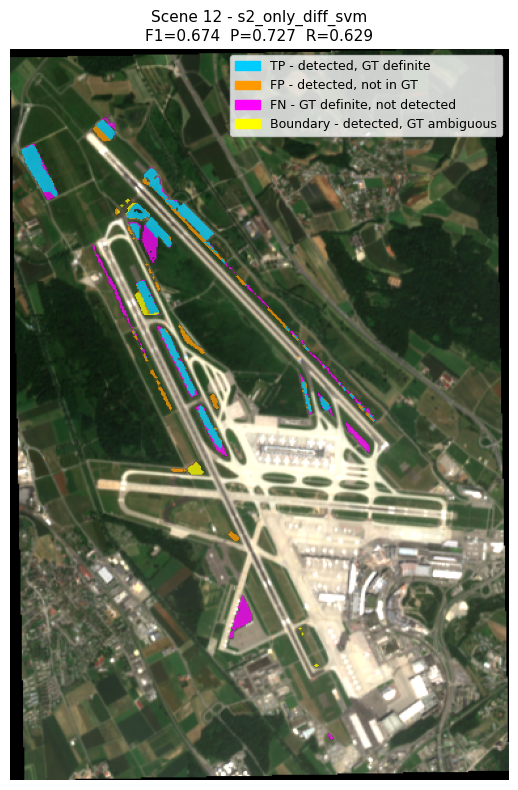


SCENE  match_id=73  event=2021-06-16 00:00:00
  before: 2021-06-13.tif  after: 2021-06-18.tif
Before: 2021-06-13.tif
After:  2021-06-18.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vh_after', 'vv_after', 'vh_diff']
  COH: 23,152 valid coh pixels
  Scene before=2021-06-13, after=2021-06-18:
    DEFINITE GT events (4): 2021-06-14, 2021-06-15, 2021-06-16, 2021-06-17
    BOUNDARY GT events (0): none
    Total GT mowed pixels: definite=4038, boundary=0
  AOI pixels: 23,152  cloud-free: 77.3%
  s2_only_best_rf: F1_raw=0.719  F1_pp=0.674  P=0.813  R=0.576
  s2_only_best_svm: F1_raw=0.649  F1_pp=0.661  P=0.544  R=0.841
  s2_only_diff_rf: F1_raw=0.602  F1_pp=0.623  P=0.544  R=0.730
  s2_only_diff_svm: F1_raw=0.625  F1_pp=0.635  P=0.537  R=0.777
  s2_best_coh_rf: F1_raw=0.677  F1_pp=0.641  P=0.810  R=0.530
  s2_diff_coh_rf: F1_raw=0.462  F1_pp=0.451  P=0.494  R=0.415
  s2_grd_rf: F1_raw=0.715  F1_pp=0.697  P=0.756  R=0.647
  full_fusion_rf: F1_raw=0.616  F1_pp=0.603  P=0.787  R=0.488
  coh_only_rf: F1_raw=0.198  F1_pp=0.199  P=0.111  R=0.917
  grd_only_rf: F1_raw=0.189  F1_pp=0.175  P=0.106  R=0.496

  Scene 73 results:
           model  F1_raw  

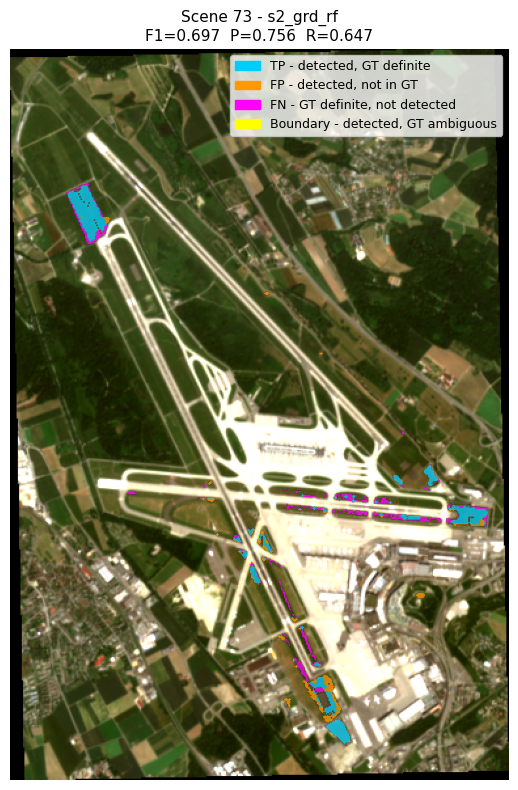

CPU times: total: 1min 2s
Wall time: 1min


In [21]:
%%time
from sklearn.metrics import precision_score, recall_score

try:
    _pp = BEST_PP
except NameError:
    _pp = {'method': 'morphological', 'disk_radius': 2, 'min_area_pixels': 4,
            'n_segments': 300, 'slic_compactness': 0.05}

all_scene_results = {}

if not EVAL_SCENE_IDS:
    print('EVAL_SCENE_IDS is empty - fill it in Section 2 and re-run.')
else:
    for mid in EVAL_SCENE_IDS:
        ev_row = matches_df[matches_df['match_id'] == mid].iloc[0]
        print(f'\n{"="*60}')
        print(f'SCENE  match_id={mid}  event={ev_row["event_date"]}')
        print(f'  before: {ev_row["before_near_file"]}  after: {ev_row["after_file"]}')

        fdf, vmask, vmask_coh, meta, H, W = load_scene_features(mid)

        date_before, date_after = _get_scene_dates(mid)
        gt_definite, gt_boundary, gt_info = build_composite_gt_mask(
            date_before, date_after, MASKS_DIR, (H, W), meta['transform'], meta['crs']
        )
        _print_gt_info(mid, gt_info, gt_definite, gt_boundary)

        n_aoi  = int(vmask.sum())
        pct_cf = inventory_df[inventory_df['match_id'] == mid]['pct_valid'].values
        print(f'  AOI pixels: {n_aoi:,}  cloud-free: {pct_cf[0] if len(pct_cf) else "?"}%')

        with rasterio.open(str(S2_DIR / ev_row['after_file'])) as src:
            rgb_ev = np.dstack([
                np.clip(src.read(3).astype(float) / 2500, 0, 1),
                np.clip(src.read(2).astype(float) / 2500, 0, 1),
                np.clip(src.read(1).astype(float) / 2500, 0, 1),
            ])

        scene_results = {}
        for mname in EVAL_MODELS:
            print(f'  {mname}:', end=' ')
            metrics = predict_and_evaluate(
                mname, fdf, vmask, vmask_coh, meta, H, W,
                gt_definite, gt_boundary,
                mid, OUTPUT_DIR, rgb_img=rgb_ev, pp_params=_pp,
            )
            if metrics:
                scene_results[mname] = metrics
                print(f'F1_raw={metrics["f1_raw"]:.3f}  F1_pp={metrics["f1_pp"]:.3f}  '
                      f'P={metrics["prec_pp"]:.3f}  R={metrics["rec_pp"]:.3f}')

        all_scene_results[mid] = scene_results

        rows = []
        for mname, m in scene_results.items():
            rows.append({
                'model':     mname,
                'F1_raw':    round(m['f1_raw'], 3),
                'F1_pp':     round(m['f1_pp'], 3),
                'Prec_pp':   round(m['prec_pp'], 3),
                'Rec_pp':    round(m['rec_pp'], 3),
                'threshold': round(m['threshold'], 3),
            })
        if rows:
            sc_df = pd.DataFrame(rows).sort_values('F1_pp', ascending=False)
            print(f'\n  Scene {mid} results:')
            print(sc_df.to_string(index=False))

        # 4-category TP/FP/FN/Boundary visualisation for best model on this scene
        if scene_results:
            best_m = max(scene_results, key=lambda k: scene_results[k]['f1_pp'])
            print(f'\n  Visualising best model: {best_m}')
            with rasterio.open(scene_results[best_m]['pp_path']) as src:
                best_pp_map = src.read(1).astype(np.int8)

            from matplotlib.patches import Patch
            fig, ax = plt.subplots(1, 1, figsize=(10, 8))
            _visualize_tp_fp_fn_boundary(
                best_pp_map, gt_definite, gt_boundary, vmask, rgb_ev,
                (f'Scene {mid} - {best_m}\n'
                 f'F1={scene_results[best_m]["f1_pp"]:.3f}  '
                 f'P={scene_results[best_m]["prec_pp"]:.3f}  '
                 f'R={scene_results[best_m]["rec_pp"]:.3f}'),
                ax,
            )
            legend_patches = [
                Patch(color='#00CCFF', label='TP - detected, GT definite'),
                Patch(color='#FF9900', label='FP - detected, not in GT'),
                Patch(color='#FF00FF', label='FN - GT definite, not detected'),
                Patch(color='#FFFF00', label='Boundary - detected, GT ambiguous'),
            ]
            ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
            plt.tight_layout()
            out_path = str(Path(IMG_DIR) / f'eval_scene{mid}_{best_m}.png')
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            print(f'  Saved: {out_path}')
            plt.show()


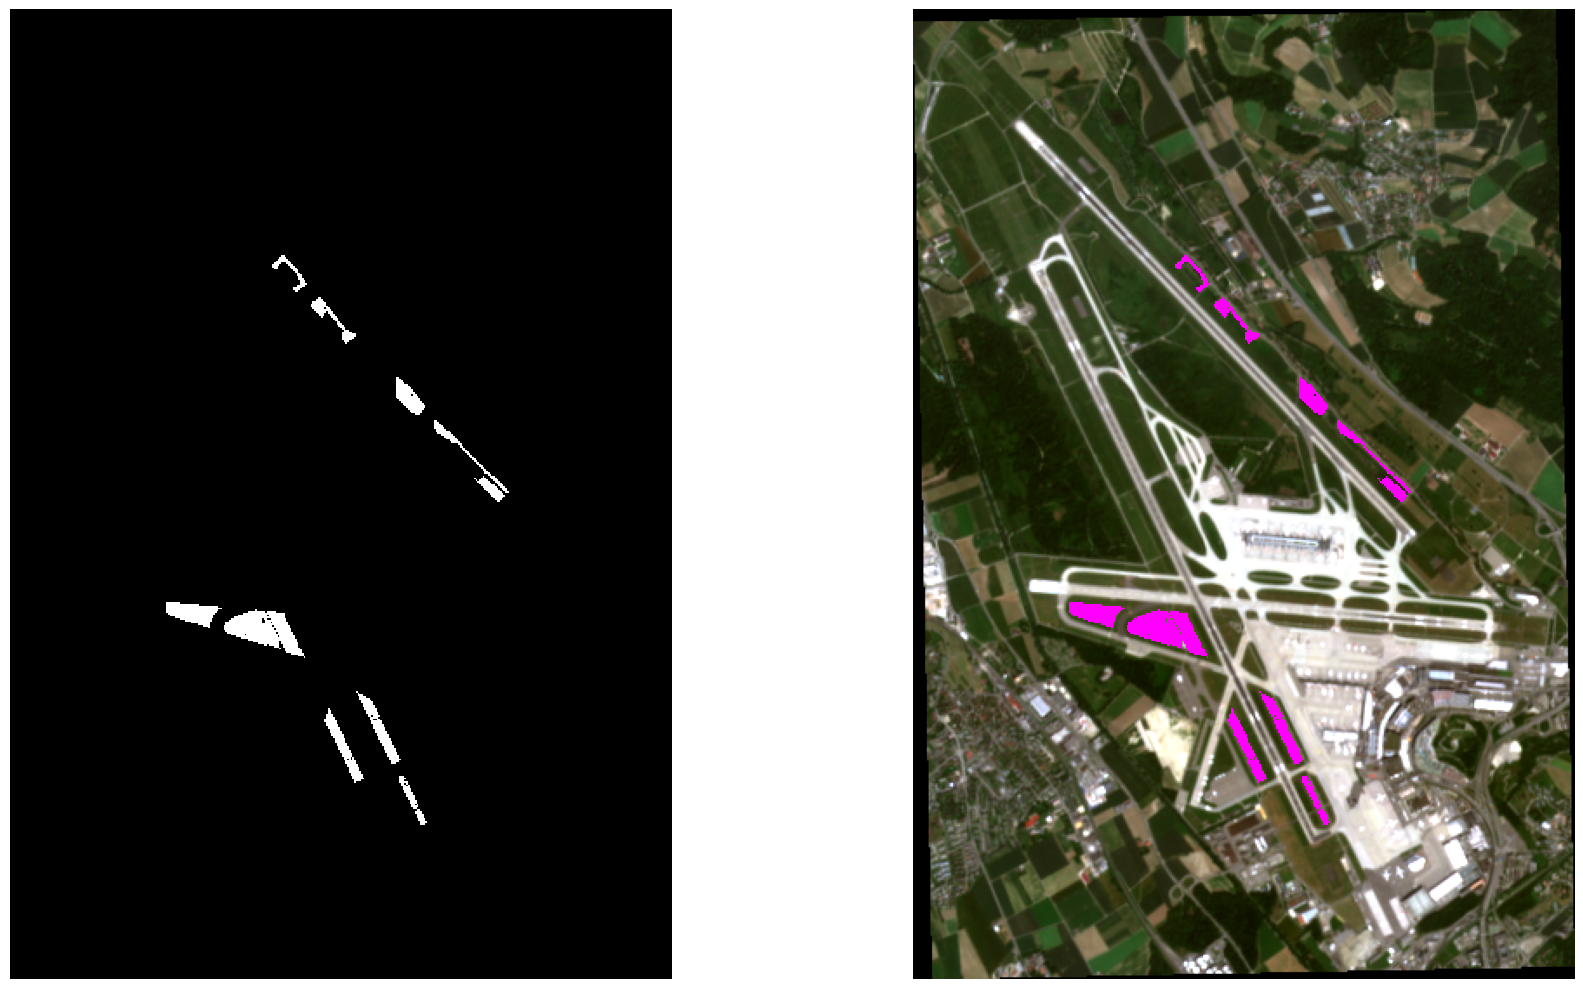

In [80]:
from matplotlib.colors import ListedColormap
# Visualize groundtruth mask from 2021-06-14
mask_path = Path(MASKS_DIR) / 'mask_20210611.tif'

example_sentinel = Path(S2_DIR) / '2021-06-18.tif'

with rasterio.open(example_sentinel) as src:
    # RGB 
    rgb = src.read([3, 2, 1]).astype(float)
    
    # Normalize for visualization
    def normalize(array):
        array_min, array_max = np.percentile(array, (2, 98))
        return np.clip((array - array_min) / (array_max - array_min), 0, 1)
    
    rgb_norm = np.stack([normalize(band) for band in rgb])

with rasterio.open(mask_path) as src:
    mask = src.read(1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Ground Truth Mask
axes[0].imshow(mask, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
#axes[0].set_title(f"Ground Truth Mask\n{os.path.basename(example_mask)}", fontsize=16)
axes[0].axis('off')

# Overlay
axes[1].imshow(np.transpose(rgb_norm, (1, 2, 0)))
mask_overlay = np.ma.masked_where(mask == 0, mask)
axes[1].imshow(mask_overlay, cmap=ListedColormap(['none', 'magenta']), alpha=1, vmin=0, interpolation='nearest')
#axes[1].set_title(f"Overlay: Sentinel-2 + Ground Truth\n{os.path.basename(example_sentinel)}", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
# Save plot as image for report
plt.show()

---
## 7. Non-Event Control Test

Validates specificity: applies the best S2 model and the best S2+Coh model to a
**pre-event** image pair (`before_far â†’ before_near`) where no mowing has occurred yet.
Mowed GT pixels should **not** be predicted as mowed.

Control test  match_id=42  (2020-05-27 00:00:00)
  Control pair (no mowing): 2020-05-14.tif -> 2020-05-24.tif
  True event:              2020-05-24.tif -> 2020-05-29.tif

Preparing control pair features...
Before: 2020-05-14.tif
After:  2020-05-24.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached to control pair
  COH: 25,204 valid coh pixels (control pair)
Preparing true event features...
Before: 2020-05-24.tif
After:  2020-05-29.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


  GRD features attached: ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
  COH: 24,498 valid coh pixels
  Scene before=2020-05-24, after=2020-05-29:
    DEFINITE GT events (3): 2020-05-26, 2020-05-27, 2020-05-28
    BOUNDARY GT events (0): none
    Total GT mowed pixels: definite=3559, boundary=0
  Definite GT mowed pixels (true event area): 3559
  full_fusion_rf control FP on GT definite area: 179/2692 = 6.6%
Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\control_test_42.png


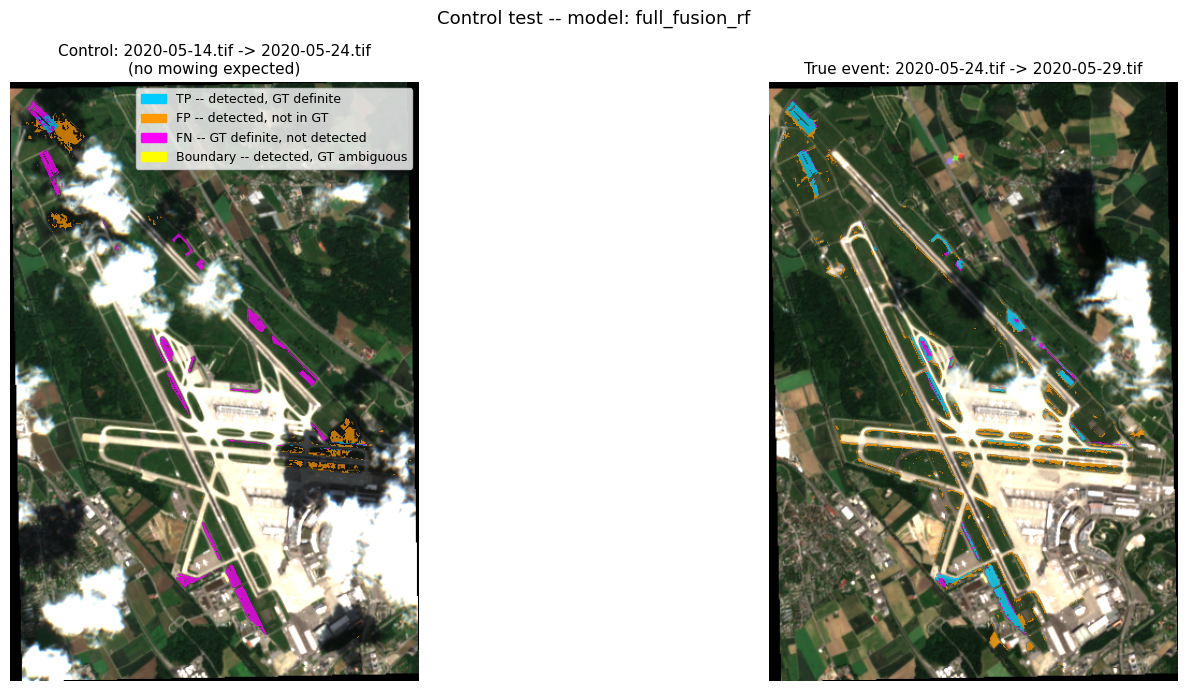

CPU times: total: 3.36 s
Wall time: 3.23 s


In [ ]:
%%time

if CONTROL_SCENE_ID is None:
    print('CONTROL_SCENE_ID is None -- set it in Section 2 and re-run.')
else:
    ctrl_row = matches_df[matches_df['match_id'] == CONTROL_SCENE_ID].iloc[0]
    bf_far_file = ctrl_row.get('before_far_file', None)

    if pd.isna(bf_far_file) or not bf_far_file:
        raise ValueError(f'match_id={CONTROL_SCENE_ID} has no before_far_file')

    bf_far_path  = str(S2_DIR / bf_far_file)
    bf_near_path = str(S2_DIR / ctrl_row['before_near_file'])
    af_path      = str(S2_DIR / ctrl_row['after_file'])

    print(f'Control test  match_id={CONTROL_SCENE_ID}  ({ctrl_row["event_date"]})')
    print(f'  Control pair (no mowing): {bf_far_file} -> {ctrl_row["before_near_file"]}')
    print(f'  True event:              {ctrl_row["before_near_file"]} -> {ctrl_row["after_file"]}')

    # S2 features for the control pair (before_far -> before_near)
    print('\nPreparing control pair features...')
    fdf_ctrl, vmask_ctrl, meta_ctrl, H_ctrl, W_ctrl = prepare_scene_features(
        bf_far_path, bf_near_path, AV_DATA_PATH, FB_DATA_PATH, FEATURE_NAMES
    )

    # Attach GRD features (same match_id spatial area, reused from true event file)
    grd_bands_ctrl = _read_grd_features(CONTROL_SCENE_ID, bf_near_path)
    if grd_bands_ctrl is not None:
        for fname in SAR_FEATURES:
            if fname in grd_bands_ctrl:
                fdf_ctrl[fname] = grd_bands_ctrl[fname]
        print(f'  GRD features attached to control pair')
    else:
        print(f'  GRD: no features TIF for match_id={CONTROL_SCENE_ID}')

    # Attach coherence features (match_id coherence files; true event period)
    coh_before_ctrl = str(Path(COH_DIR) / f'{CONTROL_SCENE_ID}_coh_before_snrcorr.tif')
    coh_after_ctrl  = str(Path(COH_DIR) / f'{CONTROL_SCENE_ID}_coh_after_snrcorr.tif')
    vmask_coh_ctrl  = np.zeros_like(vmask_ctrl)
    if Path(coh_before_ctrl).exists() and Path(coh_after_ctrl).exists():
        with rasterio.open(coh_after_ctrl) as sa:
            vv_a_idx, vh_a_idx = _find_coh_bands(sa)
        with rasterio.open(coh_before_ctrl) as sb:
            vv_b_idx, vh_b_idx = _find_coh_bands(sb)
        before_empty = _is_empty_tif(coh_before_ctrl, vv_b_idx)
        coh_a_vv = _read_coh_upsampled(coh_after_ctrl, vv_a_idx, bf_near_path)
        coh_a_vh = (_read_coh_upsampled(coh_after_ctrl, vh_a_idx, bf_near_path)
                    if vh_a_idx else np.full_like(coh_a_vv, np.nan))
        fdf_ctrl['coh_vv'] = coh_a_vv.flatten()
        fdf_ctrl['coh_vh'] = coh_a_vh.flatten()
        if before_empty:
            print(f'  COH: coh_before is all zeros -- setting jump features to 0')
            fdf_ctrl['coh_vv_jump'] = 0.0
            fdf_ctrl['coh_vh_jump'] = 0.0
        else:
            coh_b_vv = _read_coh_upsampled(coh_before_ctrl, vv_b_idx, bf_near_path)
            coh_b_vh = (_read_coh_upsampled(coh_before_ctrl, vh_b_idx, bf_near_path)
                        if vh_b_idx else np.full_like(coh_b_vv, np.nan))
            fdf_ctrl['coh_vv_jump'] = (coh_a_vv - coh_b_vv).flatten()
            fdf_ctrl['coh_vh_jump'] = (coh_a_vh - coh_b_vh).flatten()
        vmask_coh_ctrl = vmask_ctrl & np.isfinite(fdf_ctrl['coh_vv'].values)
        print(f'  COH: {vmask_coh_ctrl.sum():,} valid coh pixels (control pair)')
    else:
        print(f'  COH: no coherence TIF for match_id={CONTROL_SCENE_ID}')

    print('Preparing true event features...')
    fdf_true, vmask_true, vmask_coh_true, meta_true, H_true, W_true = load_scene_features(CONTROL_SCENE_ID)

    # Composite GT for the TRUE event window (before_near -> after)
    date_before_true, date_after_true = _get_scene_dates(CONTROL_SCENE_ID)
    gt_definite_ctrl, gt_boundary_ctrl, gt_info_ctrl = build_composite_gt_mask(
        date_before_true, date_after_true, MASKS_DIR,
        (H_ctrl, W_ctrl), meta_ctrl['transform'], meta_ctrl['crs']
    )
    _print_gt_info(CONTROL_SCENE_ID, gt_info_ctrl, gt_definite_ctrl, gt_boundary_ctrl)
    n_mowed_gt = int(gt_definite_ctrl.sum())
    print(f'  Definite GT mowed pixels (true event area): {n_mowed_gt}')

    ctrl_models = ['full_fusion_rf']
    pred_flat_c = None
    for mname in ctrl_models:
        reg = MODEL_REGISTRY[mname]
        if reg['model'] is None:
            continue

        needs_coh = NEEDS_COH[mname]
        ctrl_mask = vmask_coh_ctrl if needs_coh else vmask_ctrl

        missing = [f for f in reg['features'] if f not in fdf_ctrl.columns]
        if missing:
            print(f'  {mname}: SKIP (missing features: {missing})')
            continue
        if ctrl_mask.sum() == 0:
            print(f'  {mname}: SKIP (no valid pixels for control pair)')
            continue

        t = reg['calibrated_threshold']
        proba_ctrl   = reg['model'].predict_proba(fdf_ctrl[reg['features']][ctrl_mask])[:, 1]
        _pred_flat_c = np.full(H_ctrl * W_ctrl, -1, dtype=np.int8)
        _pred_flat_c[ctrl_mask] = (proba_ctrl >= t).astype(np.int8)

        # FP rate: model fires on definite GT-mowed pixels in the pre-event control window
        eval_mask_ctrl = ctrl_mask & ~gt_boundary_ctrl
        fp_mowed       = int(_pred_flat_c[gt_definite_ctrl & eval_mask_ctrl].clip(0, 1).sum())
        n_def_in_aoi   = int((gt_definite_ctrl & eval_mask_ctrl).sum())
        fp_rate        = fp_mowed / max(n_def_in_aoi, 1) * 100
        print(f'  {mname} control FP on GT definite area: {fp_mowed}/{n_def_in_aoi} = {fp_rate:.1f}%')

        meta_c = meta_ctrl.copy()
        meta_c.update({'count': 1, 'dtype': 'int8', 'nodata': -1})
        ctrl_pred_path = str(Path(OUTPUT_DIR) / f'ctrl_{CONTROL_SCENE_ID}_{mname}.tif')
        with rasterio.open(ctrl_pred_path, 'w', **meta_c) as dst:
            dst.write(_pred_flat_c.reshape(H_ctrl, W_ctrl), 1)

        if pred_flat_c is None:
            pred_flat_c = _pred_flat_c

    # Visualise control vs true event side by side
    best_ctrl = 'full_fusion_rf'
    bc_reg = MODEL_REGISTRY[best_ctrl]
    if bc_reg['model'] is not None and pred_flat_c is not None:
        mask_true  = vmask_coh_true if NEEDS_COH[best_ctrl] else vmask_true
        t_true = bc_reg['calibrated_threshold']
        proba_true = bc_reg['model'].predict_proba(fdf_true[bc_reg['features']][mask_true])[:, 1]
        pred_flat_t = np.full(H_true * W_true, -1, dtype=np.int8)
        pred_flat_t[mask_true] = (proba_true >= t_true).astype(np.int8)

        pred_ctrl_map = pred_flat_c.reshape(H_ctrl, W_ctrl)
        pred_true_map = pred_flat_t.reshape(H_true, W_true)

        gt_definite_true, gt_boundary_true, _ = build_composite_gt_mask(
            date_before_true, date_after_true, MASKS_DIR,
            (H_true, W_true), meta_true['transform'], meta_true['crs']
        )

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        with rasterio.open(bf_near_path) as src:
            rgb_near = np.dstack([np.clip(src.read(3).astype(float)/2500, 0, 1),
                                  np.clip(src.read(2).astype(float)/2500, 0, 1),
                                  np.clip(src.read(1).astype(float)/2500, 0, 1)])
        with rasterio.open(af_path) as src:
            rgb_after = np.dstack([np.clip(src.read(3).astype(float)/2500, 0, 1),
                                   np.clip(src.read(2).astype(float)/2500, 0, 1),
                                   np.clip(src.read(1).astype(float)/2500, 0, 1)])

        _visualize_tp_fp_fn_boundary(
            pred_ctrl_map, gt_definite_ctrl, gt_boundary_ctrl, vmask_coh_ctrl, rgb_near,
            f'Control: {bf_far_file} -> {ctrl_row["before_near_file"]}\n(no mowing expected)',
            axes[0],
        )
        _visualize_tp_fp_fn_boundary(
            pred_true_map, gt_definite_true, gt_boundary_true, mask_true, rgb_after,
            f'True event: {ctrl_row["before_near_file"]} -> {ctrl_row["after_file"]}',
            axes[1],
        )

        from matplotlib.patches import Patch
        legend_patches = [
            Patch(color='#00CCFF', label='TP -- detected, GT definite'),
            Patch(color='#FF9900', label='FP -- detected, not in GT'),
            Patch(color='#FF00FF', label='FN -- GT definite, not detected'),
            Patch(color='#FFFF00', label='Boundary -- detected, GT ambiguous'),
        ]
        axes[0].legend(handles=legend_patches, loc='upper right', fontsize=9)
        plt.suptitle(f'Control test -- model: {best_ctrl}', fontsize=13)
        plt.tight_layout()
        out_path = str(Path(IMG_DIR) / f'control_test_{CONTROL_SCENE_ID}.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {out_path}')
        plt.show()
    elif pred_flat_c is None:
        print('\nNo control-pair prediction computed -- visualization skipped.')

---
## 8. Results Summary

Comprehensive table combining all evaluation scenes and all 8 models.
Columns: model, per-scene F1\_raw, per-scene F1\_pp, Precision\_pp, Recall\_pp,
training F1 (from NB08 stored in artifact), calibrated threshold, mean F1\_pp.

Sorted by mean F1\_pp descending. Saved to `data/operational_results/eval_summary.csv`.

In [ ]:
%%time
from sklearn.metrics import precision_score, recall_score

if not EVAL_SCENE_IDS or not all_scene_results:
    print('No evaluation results - run Section 6 first.')
else:
    summary_rows = []
    for mname in EVAL_MODELS:
        reg = MODEL_REGISTRY[mname]
        train_f1 = reg.get('threshold', None)   # threshold stored; F1 not stored in artifact
        scene_metrics = {}
        for mid in EVAL_SCENE_IDS:
            m = all_scene_results.get(mid, {}).get(mname)
            if m:
                scene_metrics[mid] = m

        if not scene_metrics:
            continue

        mean_f1_pp = float(np.mean([m['f1_pp'] for m in scene_metrics.values()]))
        row = {
            'model': mname,
            'needs_coh': NEEDS_COH[mname],
            'needs_grd': NEEDS_GRD[mname],
            'calib_threshold': round(reg['calibrated_threshold'], 3),
            'mean_F1_pp': round(mean_f1_pp, 3),
        }
        for mid in EVAL_SCENE_IDS:
            m = scene_metrics.get(mid)
            prefix = f'scene{mid}'
            row[f'{prefix}_F1raw'] = round(m['f1_raw'], 3) if m else None
            row[f'{prefix}_F1pp']  = round(m['f1_pp'], 3) if m else None
            row[f'{prefix}_Prec']  = round(m['prec_pp'], 3) if m else None
            row[f'{prefix}_Rec']   = round(m['rec_pp'], 3) if m else None
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows).sort_values('mean_F1_pp', ascending=False)
    csv_path = str(Path(OUTPUT_DIR) / 'eval_summary.csv')
    summary_df.to_csv(csv_path, index=False)

    print('=== Final Evaluation Summary (sorted by mean F1_pp) ===')
    print(summary_df.to_string(index=False))
    print(f'\nSaved: {csv_path}')

    # Brief interpretation
    best_model = summary_df.iloc[0]['model']
    best_f1    = summary_df.iloc[0]['mean_F1_pp']

    s2_f1  = summary_df[summary_df['model'].str.contains('s2only')]['mean_F1_pp'].max()
    coh_f1 = summary_df[summary_df['needs_coh'] == True]['mean_F1_pp'].max()
    grd_f1 = summary_df[summary_df['needs_grd'] == True]['mean_F1_pp'].max()

    print('\n--- Interpretation ---')
    print(f'Best overall model: {best_model}  (mean F1_pp={best_f1:.3f})')
    print(f'Best S2-only F1_pp: {s2_f1:.3f}   Best +Coh F1_pp: {coh_f1:.3f}   Best +GRD F1_pp: {grd_f1:.3f}')
    if coh_f1 > s2_f1:
        print(f'Coherence adds {coh_f1 - s2_f1:+.3f} F1 over S2-only.')
    else:
        print('Coherence did NOT improve over S2-only at scene level.')
    if grd_f1 > s2_f1:
        print(f'GRD adds {grd_f1 - s2_f1:+.3f} F1 over S2-only.')
    else:
        print('GRD did NOT improve over S2-only at scene level.')
